In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("DATA\Infiltrasjonstester.csv", sep=";")

# Bytt komma til punktum og konverter til tall
for col in df.columns[1:]:
    df[col] = df[col].str.replace(",", ".").astype(float)

df.head()

,Tid i minutter,Rør 1 Københavngata,Rør 2 Københavngata,Rør 3 Københavngata,Rør 1 Deichmans gate,Rør 2 Deichmans gate,Rør 3 Deichmans gate,Rør 1 Maridalsveien,Rør 2 Maridalsveien
0,0,1.5,1.0,1.5,0.0,0.00,0.00,0.0,0.0
1,1,7.0,3.8,6.0,2.5,0.22,0.04,3.7,2.4
2,2,9.5,6.1,10.0,4.0,0.44,0.08,5.7,4.6
3,3,11.0,8.1,13.5,5.7,0.66,0.12,7.5,6.1
4,4,13.0,10.2,16.5,7.0,0.88,0.16,9.0,7.5


In [3]:
import matplotlib.pyplot as plt

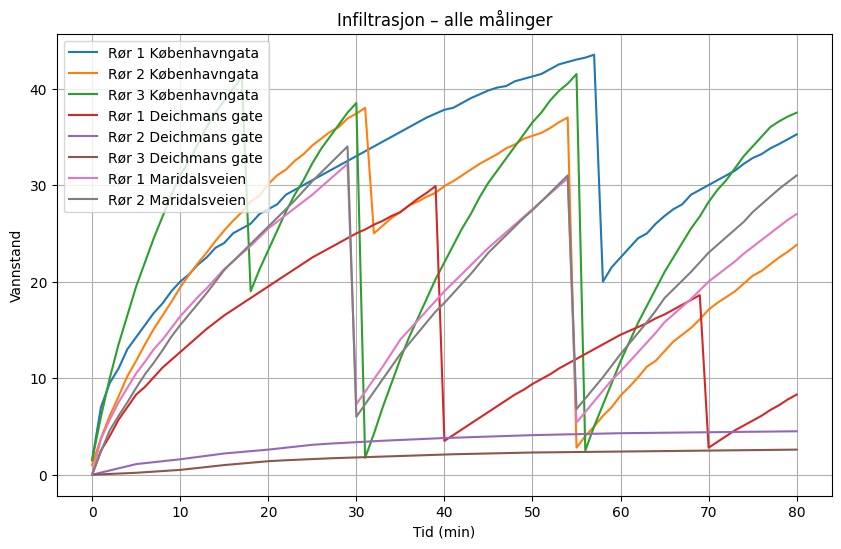

In [4]:
plt.figure(figsize=(10,6))

for col in df.columns[1:]:
    plt.plot(df["Tid i minutter"], df[col], label=col)

plt.xlabel("Tid (min)")
plt.ylabel("Vannstand")
plt.title("Infiltrasjon – alle målinger")
plt.legend()
plt.grid()
plt.show()

In [5]:
df_hastighet = df.copy()

for col in df.columns[1:]:
    diff = df[col].diff()
    
    # Sett negative verdier til NaN (fjerner reset), for å unngå negative tall.
    diff[diff < 0] = None
    
    df_hastighet[col] = diff

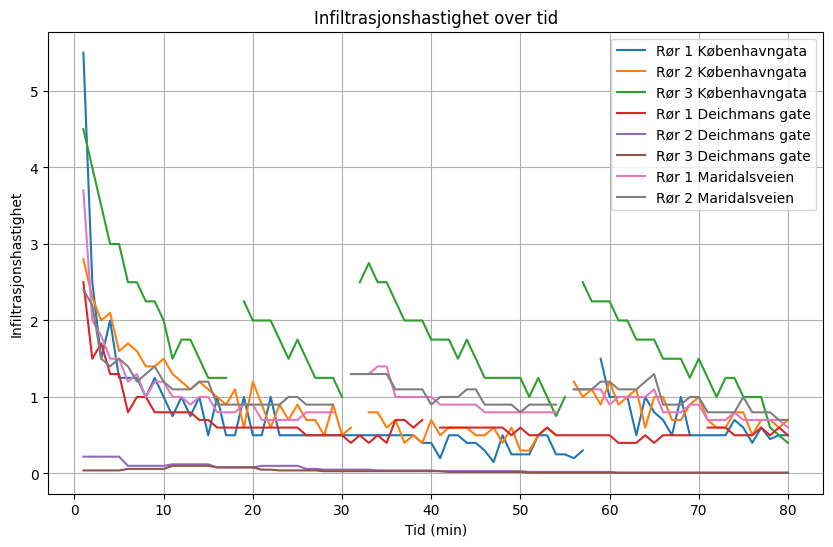

In [6]:
plt.figure(figsize=(10,6))

for col in df_hastighet.columns[1:]:
    plt.plot(df_hastighet["Tid i minutter"], df_hastighet[col], label=col)

plt.xlabel("Tid (min)")
plt.ylabel("Infiltrasjonshastighet")
plt.title("Infiltrasjonshastighet over tid")

plt.legend()
plt.grid()
plt.show()

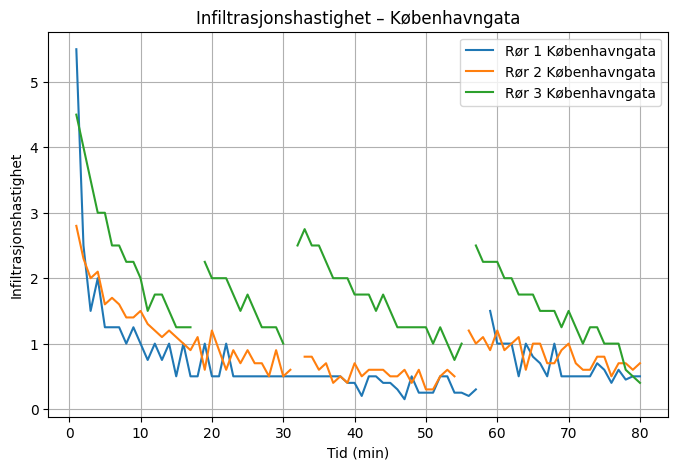

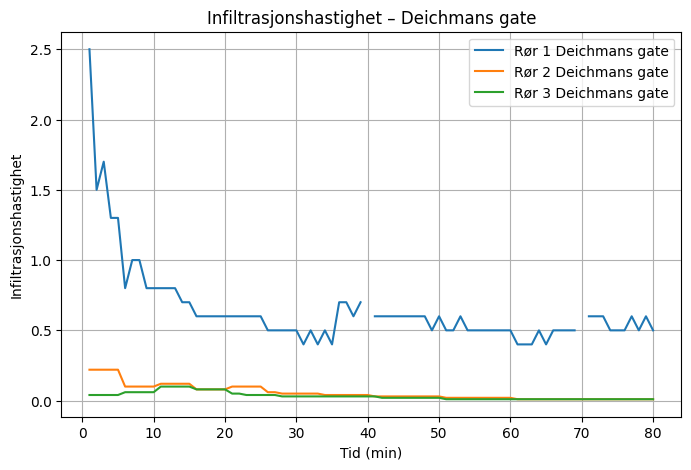

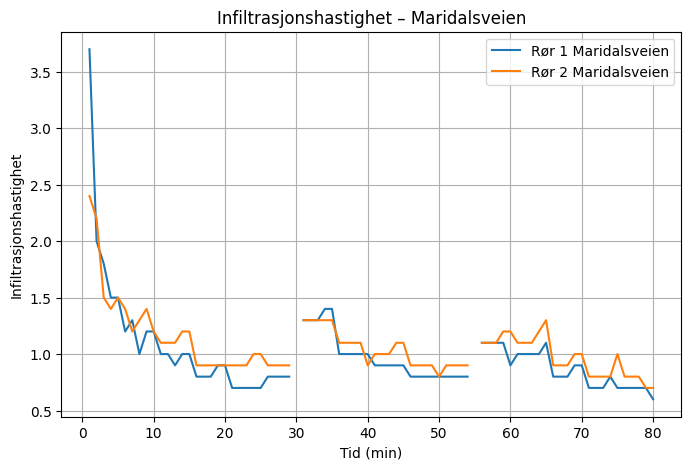

In [7]:
locations = ["Københavngata", "Deichmans gate", "Maridalsveien"]

for loc in locations:
    plt.figure(figsize=(8,5))
    
    cols = [col for col in df_hastighet.columns if loc in col]
    
    for col in cols:
        plt.plot(df_hastighet["Tid i minutter"], df_hastighet[col], label=col)
    
    plt.title(f"Infiltrasjonshastighet – {loc}")
    plt.xlabel("Tid (min)")
    plt.ylabel("Infiltrasjonshastighet")
    plt.legend()
    plt.grid()
    plt.show()

In [8]:
def finn_stabil_hastighet(series):
    # Fjern manglende verdier (NaN) fra dataserien
    s = series.dropna()
    
    # Gå bakover i serien, start nær slutten
    # Vi stopper på index 1 fordi vi ser på grupper av 3 verdier
    for i in range(len(s) - 3, 0, -1):
        
        # Hent ut 3 påfølgende verdier (et lite "vindu")
        subset = s.iloc[i:i+3]
        
        # Sjekk om verdiene er stabile:
        # forskjellen mellom maks og min må være mindre enn
        # 20 % av gjennomsnittet
        if subset.max() - subset.min() < 0.2 * subset.mean():
            
            # Hvis stabilt område er funnet:
            # returner gjennomsnittet som stabil hastighet
            return subset.mean()
    
    # Hvis vi ikke fant noe stabilt område:
    # bruk gjennomsnittet av de siste 5 verdiene som fallback
    return s.tail(5).mean()

In [9]:
# Finkornig jord (leire): Kₛₐₜ = 0,6 × stabil hastighet
# Grovkornig jord (sand/grus):Kₛₐₜ = 0,8 × stabil hastighet

ksat = {}

for col in df_hastighet.columns[1:]:
    stabil = finn_stabil_hastighet(df_hastighet[col])
    
    # Velg faktor
    if "Københavngata" in col:
        faktor = 0.8 # 50 % mellomsand og 50% siltig mellomsand. 
    elif "Maridalsveien" in col:
        faktor = 0.8 # Pukk 8-12mm med stauder.
    elif "Deichmans gate" in col:
        faktor = 0.8  # 4 % leire, 19 % silt og 77 % sand.
    
    ksat[col] = stabil * faktor

ksat_df = pd.DataFrame.from_dict(ksat, orient="index", columns=["Ksat"])
ksat_df["cm/hr"] = ksat_df["Ksat"] * 60
ksat_df

,Ksat,cm/hr
Rør 1 Københavngata,0.386667,23.20
Rør 2 Københavngata,0.533333,32.00
Rør 3 Københavngata,0.800000,48.00
Rør 1 Deichmans gate,0.426667,25.60
Rør 2 Deichmans gate,0.008000,0.48
Rør 3 Deichmans gate,0.008000,0.48
Rør 1 Maridalsveien,0.533333,32.00
Rør 2 Maridalsveien,0.586667,35.20


In [11]:
import pandas as pd
import numpy as np
from scipy import stats

resultater = []

for col in df_hastighet.columns:
    data = df_hastighet[col].dropna()
    
    mean = data.mean()
    std = data.std()
    n = len(data)
    
    # 95% konfidensintervall (t-fordeling)
    ci_low, ci_high = stats.t.interval(
        0.95, df=n-1, loc=mean, scale=std/np.sqrt(n)
    )
    
    resultater.append({
        "Rør": col,
        "Mean": mean,
        "Std": std,
        "N": n,
        "CI_lower": ci_low,
        "CI_upper": ci_high
    })

df_stats = pd.DataFrame(resultater)
df_stats

,Rør,Mean,Std,N,CI_lower,CI_upper
0,Tid i minutter,40.000000,23.526581,81,34.797846,45.202154
1,Rør 1 Københavngata,0.724684,0.675338,79,0.573416,0.875951
2,Rør 2 Københavngata,0.897436,0.458958,78,0.793957,1.000915
3,Rør 3 Københavngata,1.740260,0.728419,77,1.574929,1.905591
4,Rør 1 Deichmans gate,0.647436,0.314054,78,0.576628,0.718244
5,Rør 2 Deichmans gate,0.056250,0.055264,80,0.043952,0.068548
6,Rør 3 Deichmans gate,0.032500,0.026553,80,0.026591,0.038409
7,Rør 1 Maridalsveien,0.989744,0.403102,78,0.898858,1.080629
8,Rør 2 Maridalsveien,1.066667,0.275241,78,1.004609,1.128724


In [12]:
stabilitet_resultater = []

for col in df_hastighet.columns:
    data = df_hastighet[col].dropna()
    
    siste = data.tail(5)
    
    mean = siste.mean()
    max_val = siste.max()
    min_val = siste.min()
    
    # prosentvis variasjon
    variation_percent = (max_val - min_val) / mean * 100
    
    stabil = variation_percent <= 20
    
    stabilitet_resultater.append({
        "Rør": col,
        "Mean_last5": mean,
        "Max": max_val,
        "Min": min_val,
        "Variation_%": variation_percent,
        "Stabil (Ksat)": stabil
    })

df_stabilitet = pd.DataFrame(stabilitet_resultater)
df_stabilitet

,Rør,Mean_last5,Max,Min,Variation_%,Stabil (Ksat)
0,Tid i minutter,78.00,80.00,76.00,5.128205e+00,True
1,Rør 1 Københavngata,0.49,0.60,0.40,4.081633e+01,False
2,Rør 2 Københavngata,0.64,0.70,0.50,3.125000e+01,False
3,Rør 3 Københavngata,0.70,1.00,0.40,8.571429e+01,False
4,Rør 1 Deichmans gate,0.54,0.60,0.50,1.851852e+01,True
5,Rør 2 Deichmans gate,0.01,0.01,0.01,8.881784e-12,True
6,Rør 3 Deichmans gate,0.01,0.01,0.01,4.440892e-12,True
7,Rør 1 Maridalsveien,0.68,0.70,0.60,1.470588e+01,True
8,Rør 2 Maridalsveien,0.76,0.80,0.70,1.315789e+01,True


In [13]:
df_final = pd.merge(df_stats, df_stabilitet, on="Rør")
df_final

,Rør,Mean,Std,N,CI_lower,CI_upper,Mean_last5,Max,Min,Variation_%,Stabil (Ksat)
0,Tid i minutter,40.000000,23.526581,81,34.797846,45.202154,78.00,80.00,76.00,5.128205e+00,True
1,Rør 1 Københavngata,0.724684,0.675338,79,0.573416,0.875951,0.49,0.60,0.40,4.081633e+01,False
2,Rør 2 Københavngata,0.897436,0.458958,78,0.793957,1.000915,0.64,0.70,0.50,3.125000e+01,False
3,Rør 3 Københavngata,1.740260,0.728419,77,1.574929,1.905591,0.70,1.00,0.40,8.571429e+01,False
4,Rør 1 Deichmans gate,0.647436,0.314054,78,0.576628,0.718244,0.54,0.60,0.50,1.851852e+01,True
5,Rør 2 Deichmans gate,0.056250,0.055264,80,0.043952,0.068548,0.01,0.01,0.01,8.881784e-12,True
6,Rør 3 Deichmans gate,0.032500,0.026553,80,0.026591,0.038409,0.01,0.01,0.01,4.440892e-12,True
7,Rør 1 Maridalsveien,0.989744,0.403102,78,0.898858,1.080629,0.68,0.70,0.60,1.470588e+01,True
8,Rør 2 Maridalsveien,1.066667,0.275241,78,1.004609,1.128724,0.76,0.80,0.70,1.315789e+01,True


Tolkning av statistiske resultater og stabilitet (Ksat)

Tabellen viser både statistiske mål for infiltrasjonshastighet og en vurdering av hvorvidt mettet hydraulisk konduktivitet (Ksat) er oppnådd. Gjennomsnittsverdiene (Mean) varierer tydelig mellom lokalitetene, der Deichmans gate har svært lave infiltrasjonsrater (~0.03–0.06), mens Københavngata og Maridalsveien ligger betydelig høyere (~0.7–1.7). Dette indikerer store forskjeller i jordas permeabilitet mellom områdene.

Standardavviket er generelt høyest for Københavngata, noe som tyder på større variasjon i infiltrasjonsevne innen samme område. Dette er forventet for urban jord, hvor massene ofte er heterogene. Samtidig er konfidensintervallene relativt smale for alle målinger, noe som indikerer at gjennomsnittsverdiene er statistisk robuste.

For vurdering av Ksat er de siste målingene analysert. Stabil infiltrasjon (±20 % variasjon) er oppnådd for alle rør ved Deichmans gate og Maridalsveien, samt for Rør 1 ved Deichmans gate. Dette tyder på at målingene her representerer mettet hydraulisk konduktivitet.

For alle rør ved Københavngata overstiger variasjonen 20 %, noe som indikerer at infiltrasjonshastigheten fortsatt var i avtakende fase og at jorda ikke var fullt mettet. Dette innebærer at de beregnede verdiene her ikke nødvendigvis representerer reell Ksat, og kan være overestimert.

Samlet viser resultatene at lavpermeable masser (Deichmans gate) oppnår stabil tilstand raskt, mens mer permeable og heterogene masser (Københavngata) krever lengre tid for å nå metning.